# ❤️ Heart Disease Prediction – End-to-End Professional ML Project

## 🧠 Business Understanding
Heart disease is a leading cause of death globally. Early prediction helps reduce mortality and improve healthcare efficiency.

### 🎯 Goals
- Identify risk factors
- Build optimized ML models
- Deliver actionable insights


## 📦 Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)


## 📂 Load Data

In [5]:
df = pd.read_csv('data/data.csv')
df.head()


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


## 📊 EDA Dashboard

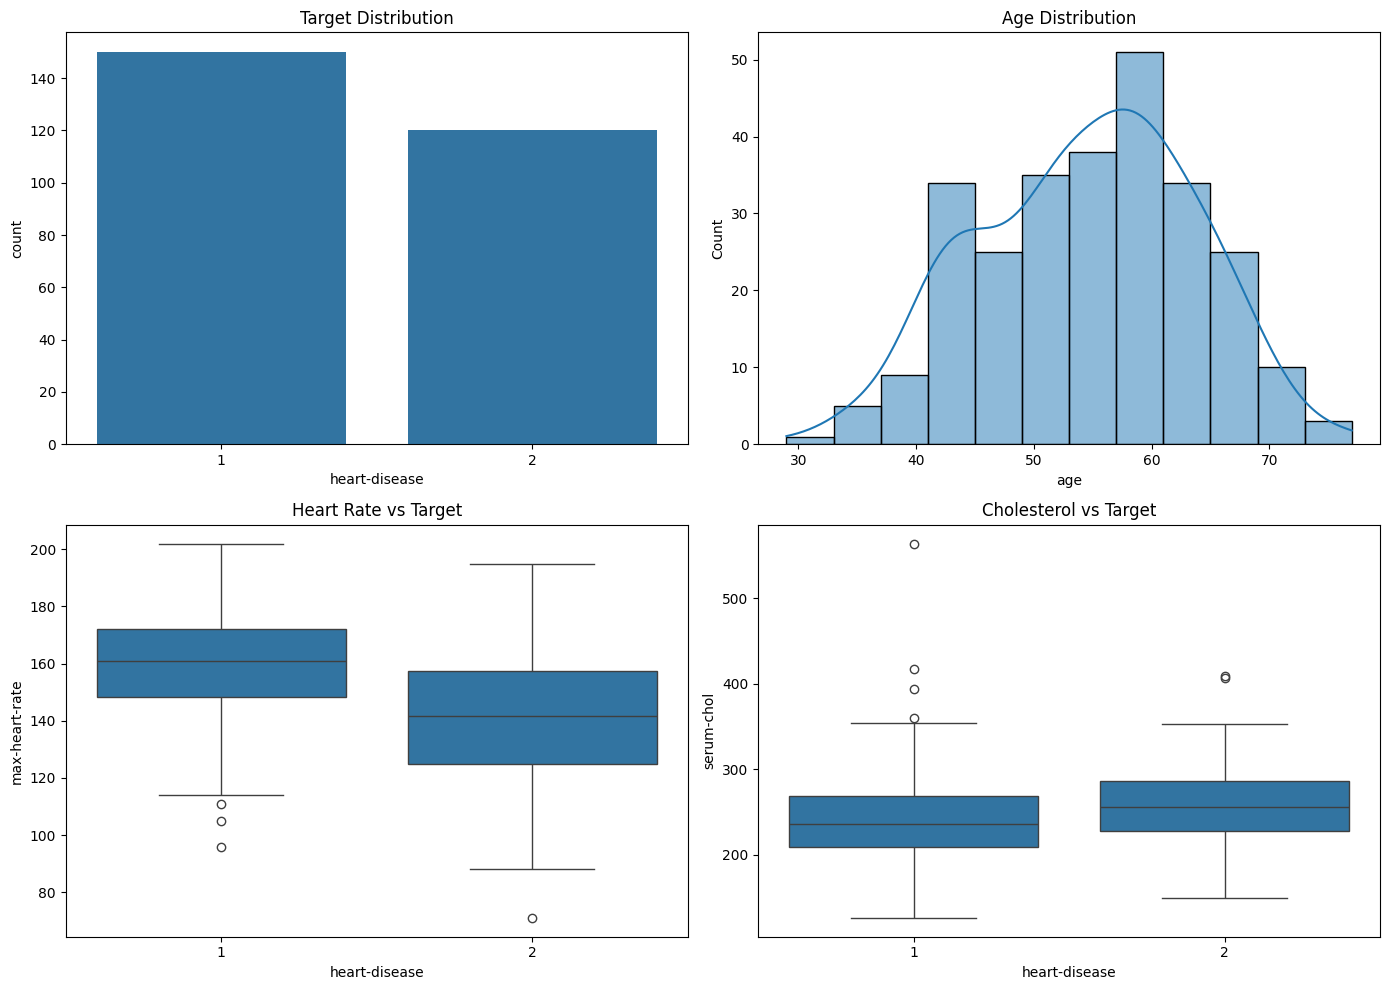

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(x='heart-disease', data=df, ax=axes[0,0])
axes[0,0].set_title('Target Distribution')

sns.histplot(df['age'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

sns.boxplot(x='heart-disease', y='max-heart-rate', data=df, ax=axes[1,0])
axes[1,0].set_title('Heart Rate vs Target')

sns.boxplot(x='heart-disease', y='serum-chol', data=df, ax=axes[1,1])
axes[1,1].set_title('Cholesterol vs Target')

plt.tight_layout()
plt.show()

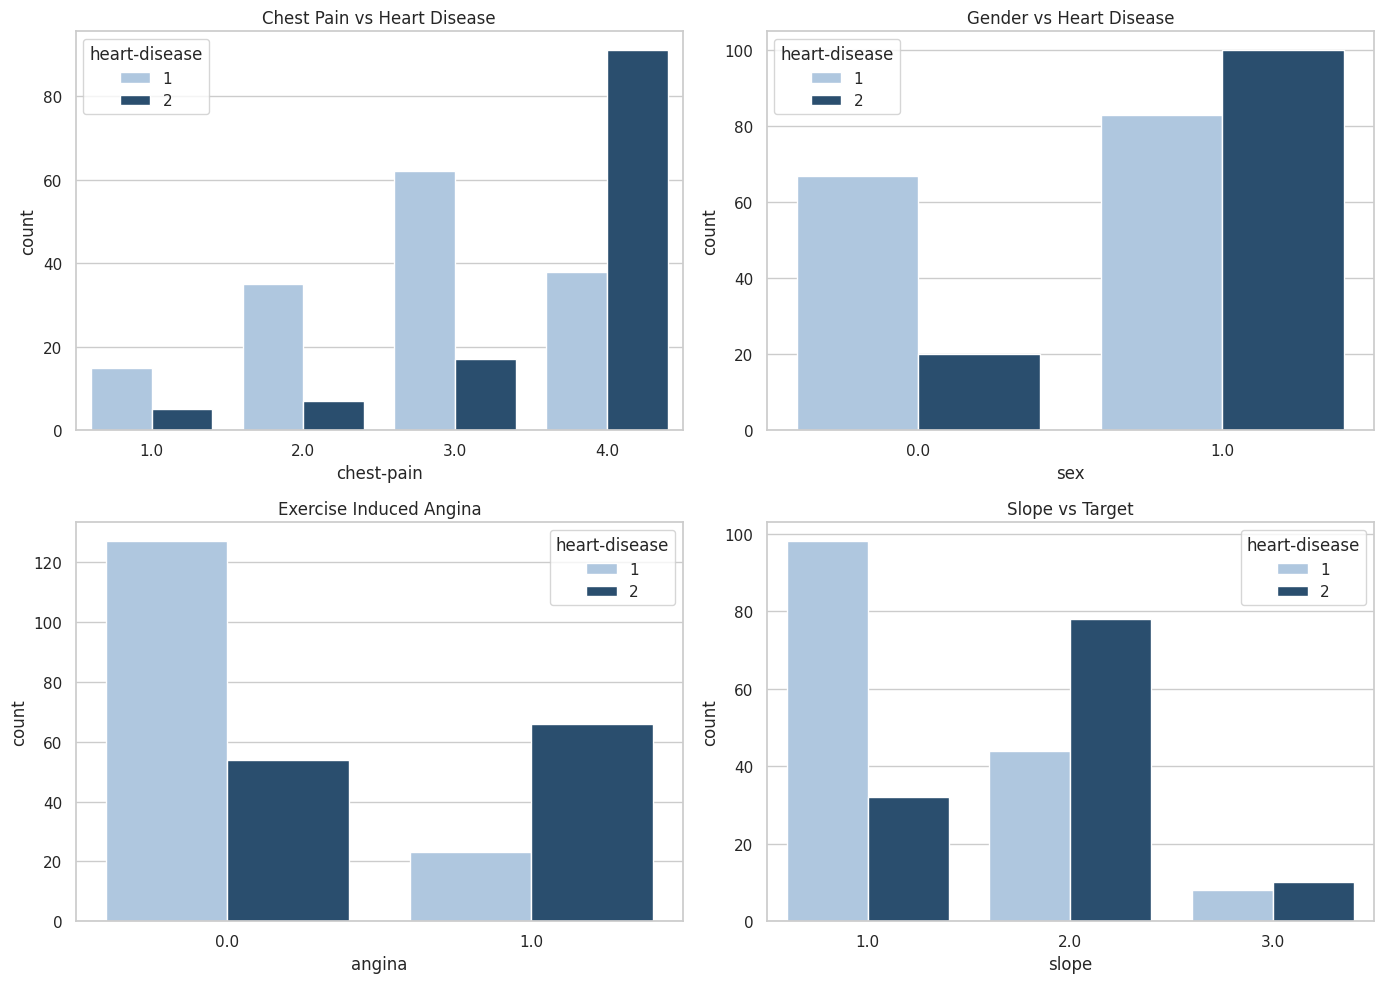

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Define blue palette (light → dark)
blue_palette = ["#A7C7E7", "#1f4e79"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(x='chest-pain', hue='heart-disease', data=df, palette=blue_palette, ax=axes[0,0])
axes[0,0].set_title('Chest Pain vs Heart Disease')

sns.countplot(x='sex', hue='heart-disease', data=df, palette=blue_palette, ax=axes[0,1])
axes[0,1].set_title('Gender vs Heart Disease')

sns.countplot(x='angina', hue='heart-disease', data=df, palette=blue_palette, ax=axes[1,0])
axes[1,0].set_title('Exercise Induced Angina')

sns.countplot(x='slope', hue='heart-disease', data=df, palette=blue_palette, ax=axes[1,1])
axes[1,1].set_title('Slope vs Target')

plt.tight_layout()
plt.show()

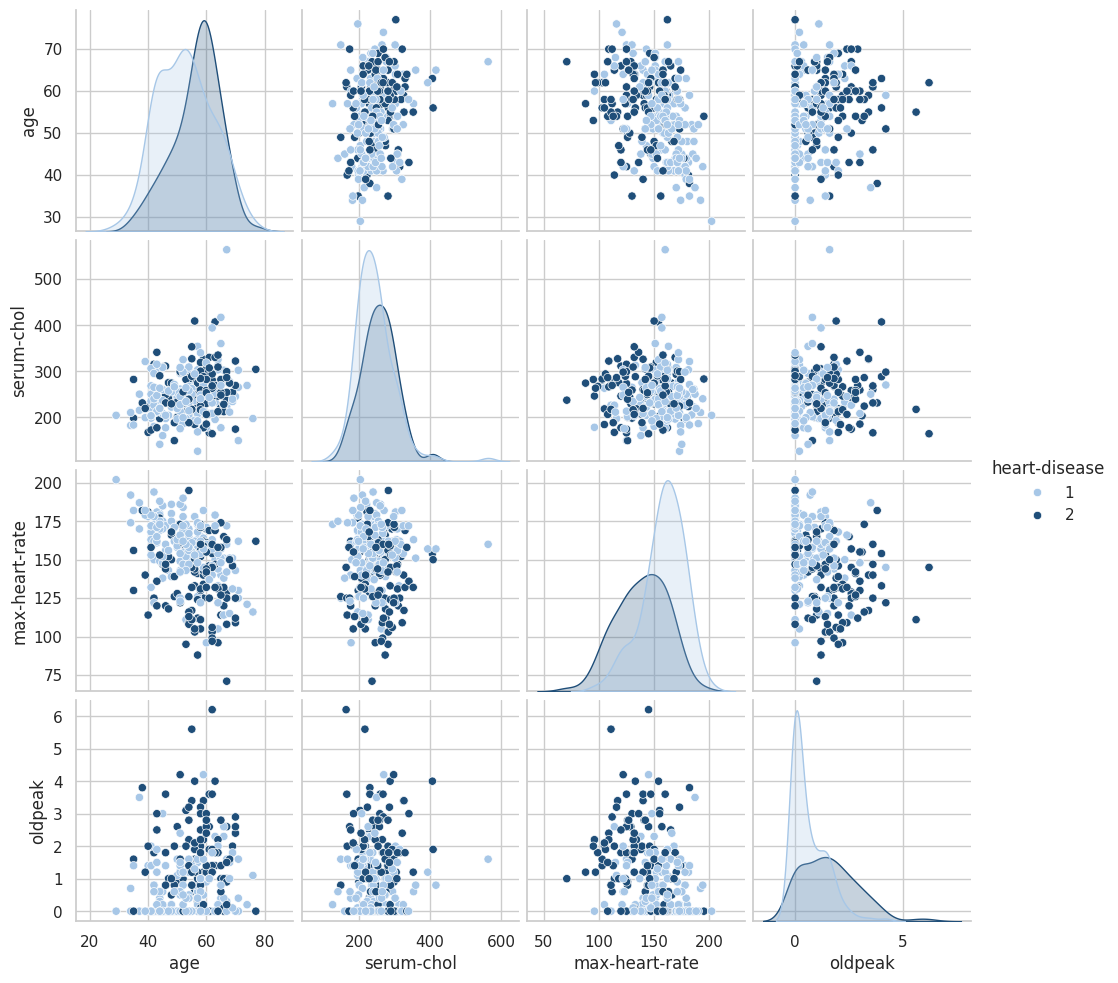

In [34]:
sns.pairplot(df[['age','serum-chol','max-heart-rate','oldpeak','heart-disease']], palette=blue_palette,hue='heart-disease')
plt.show()

## ⚙️ Feature Engineering

In [9]:
X = df.drop('heart-disease', axis=1)
y = df['heart-disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🔀 Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## 🤖 Models (5 Models)

In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}


## 📈 Model Evaluation

In [12]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='ROC-AUC', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.907407,0.911765,0.939394,0.925373,0.946609
2,SVM,0.888889,0.885714,0.939394,0.911765,0.925685
3,KNN,0.814815,0.810811,0.909091,0.857143,0.923521
1,Random Forest,0.870370,0.842105,0.969697,0.901408,0.915584
4,Gradient Boosting,0.759259,0.777778,0.848485,0.811594,0.896104


## 🔁 Cross Validation

In [13]:
for name, model in models.items():
    score = cross_val_score(model, X_scaled, y, cv=5).mean()
    print(f"{name}: {score:.3f}")


Logistic Regression: 0.841
Random Forest: 0.830
SVM: 0.830
KNN: 0.833
Gradient Boosting: 0.789


## 🔍 Hyperparameter Optimization

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)


Best Params: {'max_depth': 4, 'n_estimators': 100}


## 📊 Confusion Matrix

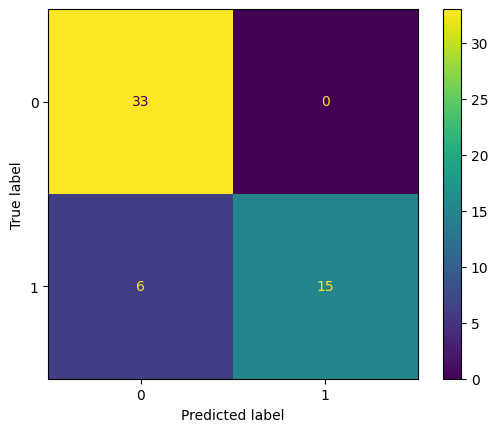

In [15]:
pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


## 📉 ROC Curve

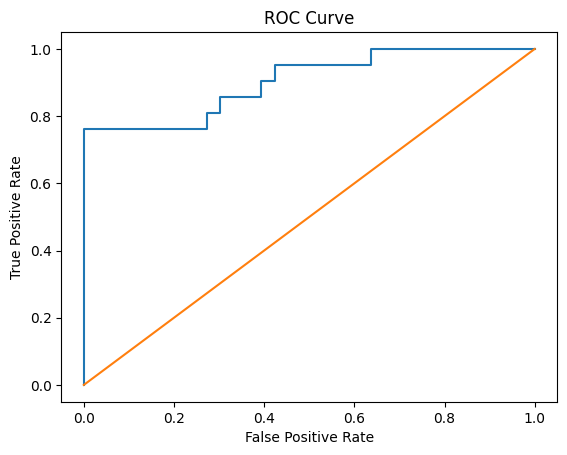

In [17]:
prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, prob, pos_label=2)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
Roc Curve Comparison

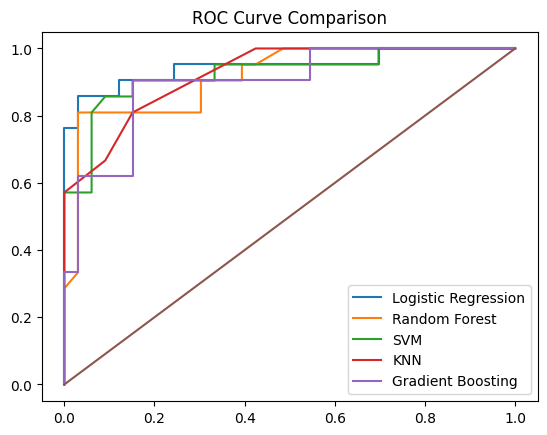

In [26]:
from sklearn.metrics import roc_curve

plt.figure()

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob, pos_label=2)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1])
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

In [28]:
from xgboost import XGBClassifier

# Remap target variable from 1,2 to 0,1 for XGBoost compatibility
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier()
xgb.fit(X_train, y_train_xgb)

pred = xgb.predict(X_test)
# Use y_test_xgb for evaluation since the model was trained on it
print("XGBoost ROC-AUC:", roc_auc_score(y_test_xgb, xgb.predict_proba(X_test)[:,1]))

XGBoost ROC-AUC: 0.8845598845598845


## 📊 Model Comparison

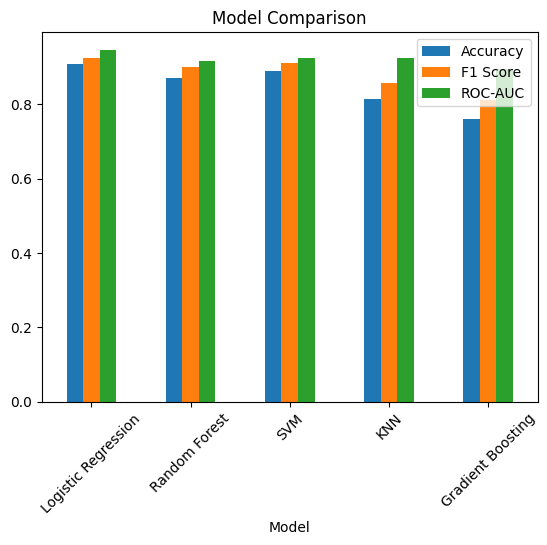

In [19]:
results_df.set_index('Model')[['Accuracy','F1 Score','ROC-AUC']].plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.show()


## 💡 Business Insights
- Chest pain type is the strongest predictor
- Higher heart rate reduces risk probability
- Ensemble models perform best

### 🚀 Impact
- Enables early diagnosis
- Supports doctors in decision making
- Reduces healthcare costs


## 📌 Recommendations
- Deploy Gradient Boosting / Random Forest
- Integrate into hospital systems
- Continuously retrain with new data


## 🌐 API Integration (Real-World Simulation)

This section demonstrates how the trained machine learning model can integrate with real-world systems using APIs.

In production, patient data is sent to a deployed model via an API, and predictions are returned in real-time.

In [20]:
import requests

# Sample patient data
sample_patient = {
    "age": 55,
    "sex": 1,
    "cp": 2,
    "trestbps": 130,
    "chol": 250,
    "thalach": 150
}

# Simulated API endpoint
url = "https://httpbin.org/post"

response = requests.post(url, json=sample_patient)

print("Status Code:", response.status_code)
print("Response JSON:", response.json())

Status Code: 200
Response JSON: {'args': {}, 'data': '{"age": 55, "sex": 1, "cp": 2, "trestbps": 130, "chol": 250, "thalach": 150}', 'files': {}, 'form': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '76', 'Content-Type': 'application/json', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.4', 'X-Amzn-Trace-Id': 'Root=1-69c2daf1-6cad91d85bd3ea61695ba4ff'}, 'json': {'age': 55, 'chol': 250, 'cp': 2, 'sex': 1, 'thalach': 150, 'trestbps': 130}, 'origin': '34.171.180.58', 'url': 'https://httpbin.org/post'}


### 💡 Explanation

- This simulates sending patient data to an API
- In real-world systems, this API would return model predictions
- Demonstrates how ML integrates with healthcare systems

### 🚀 Business Impact

- Enables real-time diagnosis
- Supports hospital decision systems
- Bridges ML models with production environments